# EDA Histórico Chat

---

## Objetivo

O objetivo desse notebook é realizar uma análise exploratória nos dados de chat histórico breve que serão utilizados posteriormente para predizer a autoria de cada mensagem. O notebook salvará um dataset de **treino** e **teste** do modelo.

---

## Código

---

In [5]:
import re
import pandas as pd
import numpy as np

with open("../dados/raw/chat.txt", "r") as f:
    texto = f.read()

pattern = r"\[(\d{1,2}/\d{1,2}/\d{2},\s*\d{1,2}:\d{2}:\d{2}\s*(?:AM|PM|am|pm))\]\s*(?!\s*[-~])([^\n:\]]+?):\s*(.*?)(?=\n\[\d{1,2}/\d{1,2}/\d{2},|\Z)"

matches = re.findall(pattern, texto, flags=re.DOTALL)

df = pd.DataFrame(matches, columns=["data_hora", "membro", "mensagem"])

df["mensagem"] = df["mensagem"].str.strip()

df["data_hora"] = pd.to_datetime(df["data_hora"], format = "%m/%d/%y, %I:%M:%S %p")

print("Primeiras linhas dos dados")
print(df.head())
print("Informações adicionais")
print(df.info())
print("Total de valores nulos")
print(df.isnull().sum())

Primeiras linhas dos dados
            data_hora   membro                        mensagem
0 2026-03-10 14:47:48  Luquete                     não precisa
1 2026-03-10 14:47:54  Luquete  e só colocar barco no enderman
2 2026-03-10 14:47:56    André       onde fica os piglin bruto
3 2026-03-10 14:47:58  Luquete       ele não consegue te bater
4 2026-03-10 14:48:04    André                     vai demorar
Informações adicionais
<class 'pandas.DataFrame'>
RangeIndex: 99707 entries, 0 to 99706
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   data_hora  99707 non-null  datetime64[us]
 1   membro     99707 non-null  str           
 2   mensagem   99707 non-null  str           
dtypes: datetime64[us](1), str(2)
memory usage: 5.4 MB
None
Total de valores nulos
data_hora    0
membro       0
mensagem     0
dtype: int64


/tmp/ipykernel_25617/8351467.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
findfont: Failed to find font weight medium for DejaVu Sans, now using 400.


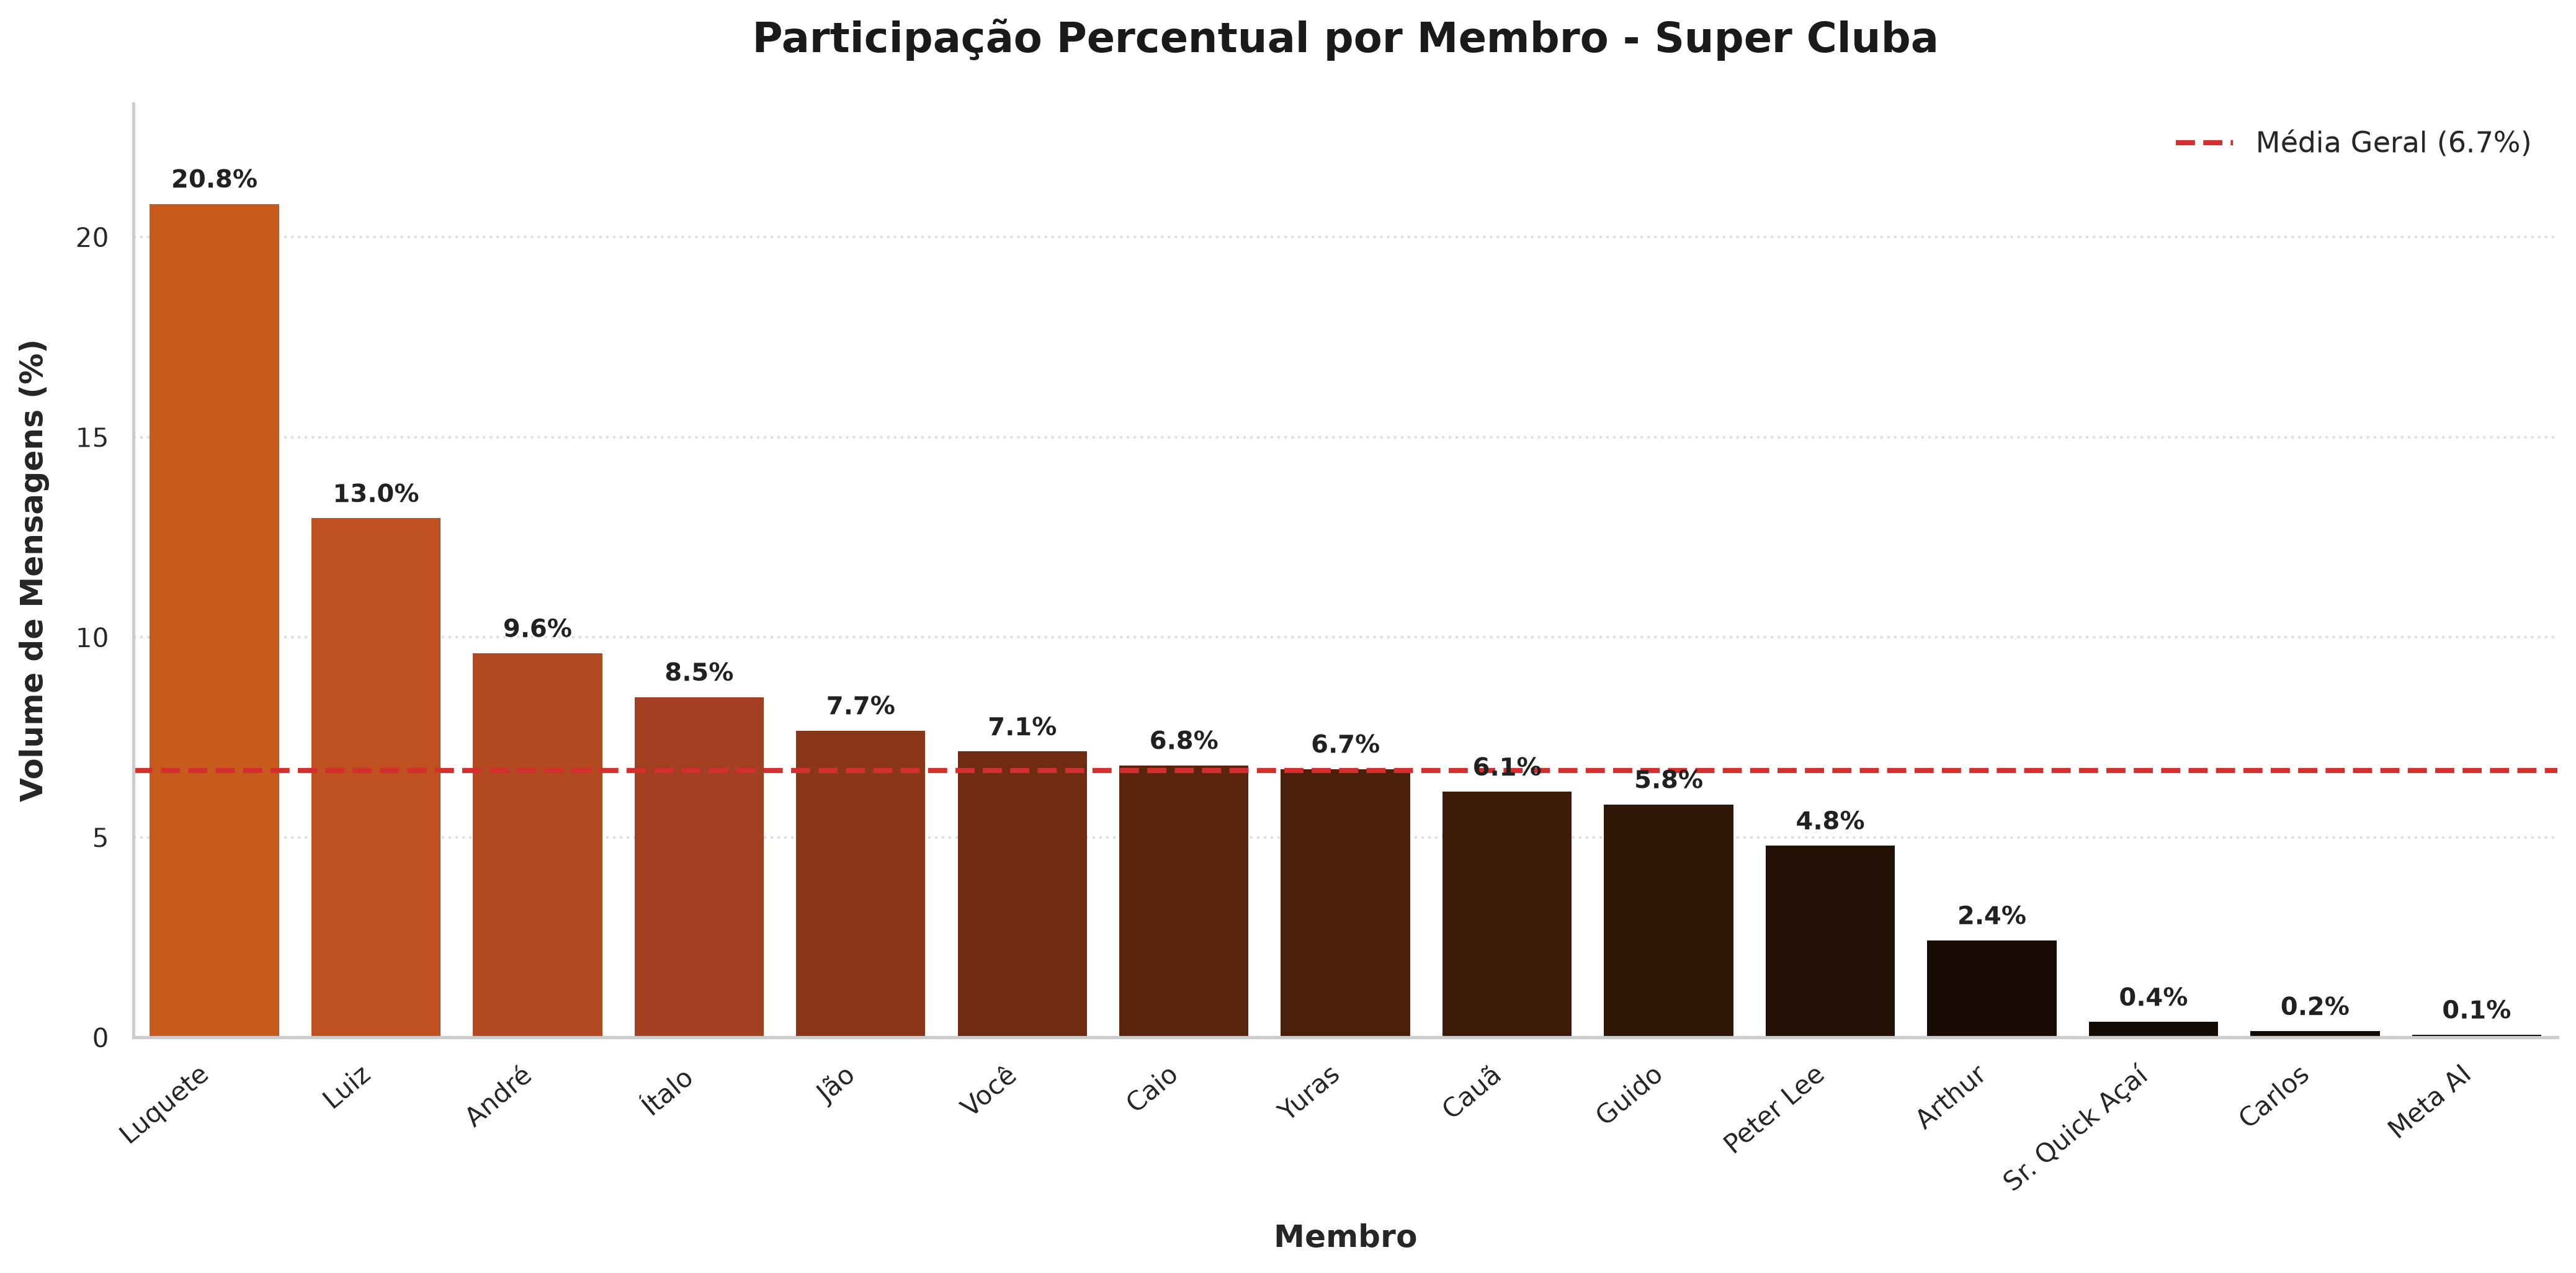

In [6]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

df_membros = df["membro"].value_counts(normalize=True).reset_index()
df_membros.columns = ["membro", "percentual"]
df_membros["percentual"] = df_membros["percentual"] * 100

total_membros = len(df_membros)
media_percentual = df_membros["percentual"].mean()

sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7), dpi=300)

cores_degrade = ["#E65100", "#BF360C", "#6D2100", "#3E1700", "#1A0B00", "#0B0B0B"]
cmap_custom = mcolors.LinearSegmentedColormap.from_list(
    "laranja_preto", cores_degrade, N=total_membros
)
paleta = [cmap_custom(i / (total_membros - 1)) for i in range(total_membros)]

ax = sns.barplot(
    data=df_membros,
    x="membro",
    y="percentual",
    palette=paleta,
    edgecolor="none",
)

plt.axhline(
    y=media_percentual,
    color="#D32F2F",
    linestyle="--",
    linewidth=2,
    label=f"Média Geral ({media_percentual:.1f}%)",
)

for p in ax.patches:
    altura = p.get_height()
    if altura > 0:
        ax.annotate(
            f"{altura:.1f}%",
            (p.get_x() + p.get_width() / 2.0, altura),
            ha="center",
            va="bottom",
            fontsize=9.5,
            fontweight="bold",
            color="#212121",
            xytext=(0, 4),
            textcoords="offset points",
        )

plt.title(
    "Participação Percentual por Membro - Super Cluba",
    fontsize=16,
    fontweight="bold",
    pad=20,
    color="#1A1A1A",
)
plt.xlabel("Membro", fontsize=12, fontweight="bold", labelpad=10)
plt.ylabel(
    "Volume de Mensagens (%)", fontsize=12, fontweight="bold", labelpad=10
)

plt.xticks(rotation=40, ha="right", fontsize=10, fontweight="medium")
plt.yticks(fontsize=10)
plt.ylim(0, df_membros["percentual"].max() * 1.12)

sns.despine(top=True, right=True)
plt.grid(axis="y", linestyle=":", alpha=0.6)
plt.legend(
    frameon=True,
    facecolor="white",
    edgecolor="none",
    fontsize=11,
    loc="upper right",
)

plt.tight_layout()
plt.show()

Sendo o membro nossa variável target, o desbalanceamento da distribuição nos aponta um possível problema mais a frente, devemos ter cuidado na hora de balancear pesos no modelo e entender que de agora em diante, nossa métrica será baseada em F1 Score Macro. 

Por motivos de não estarem mais no grupo e participarem um total de 0.3% das mensagens totais vamos retirar **Carlos** e **Meta AI**.

In [7]:
df = df[~df["membro"].isin(["Carlos", "Meta AI"])]

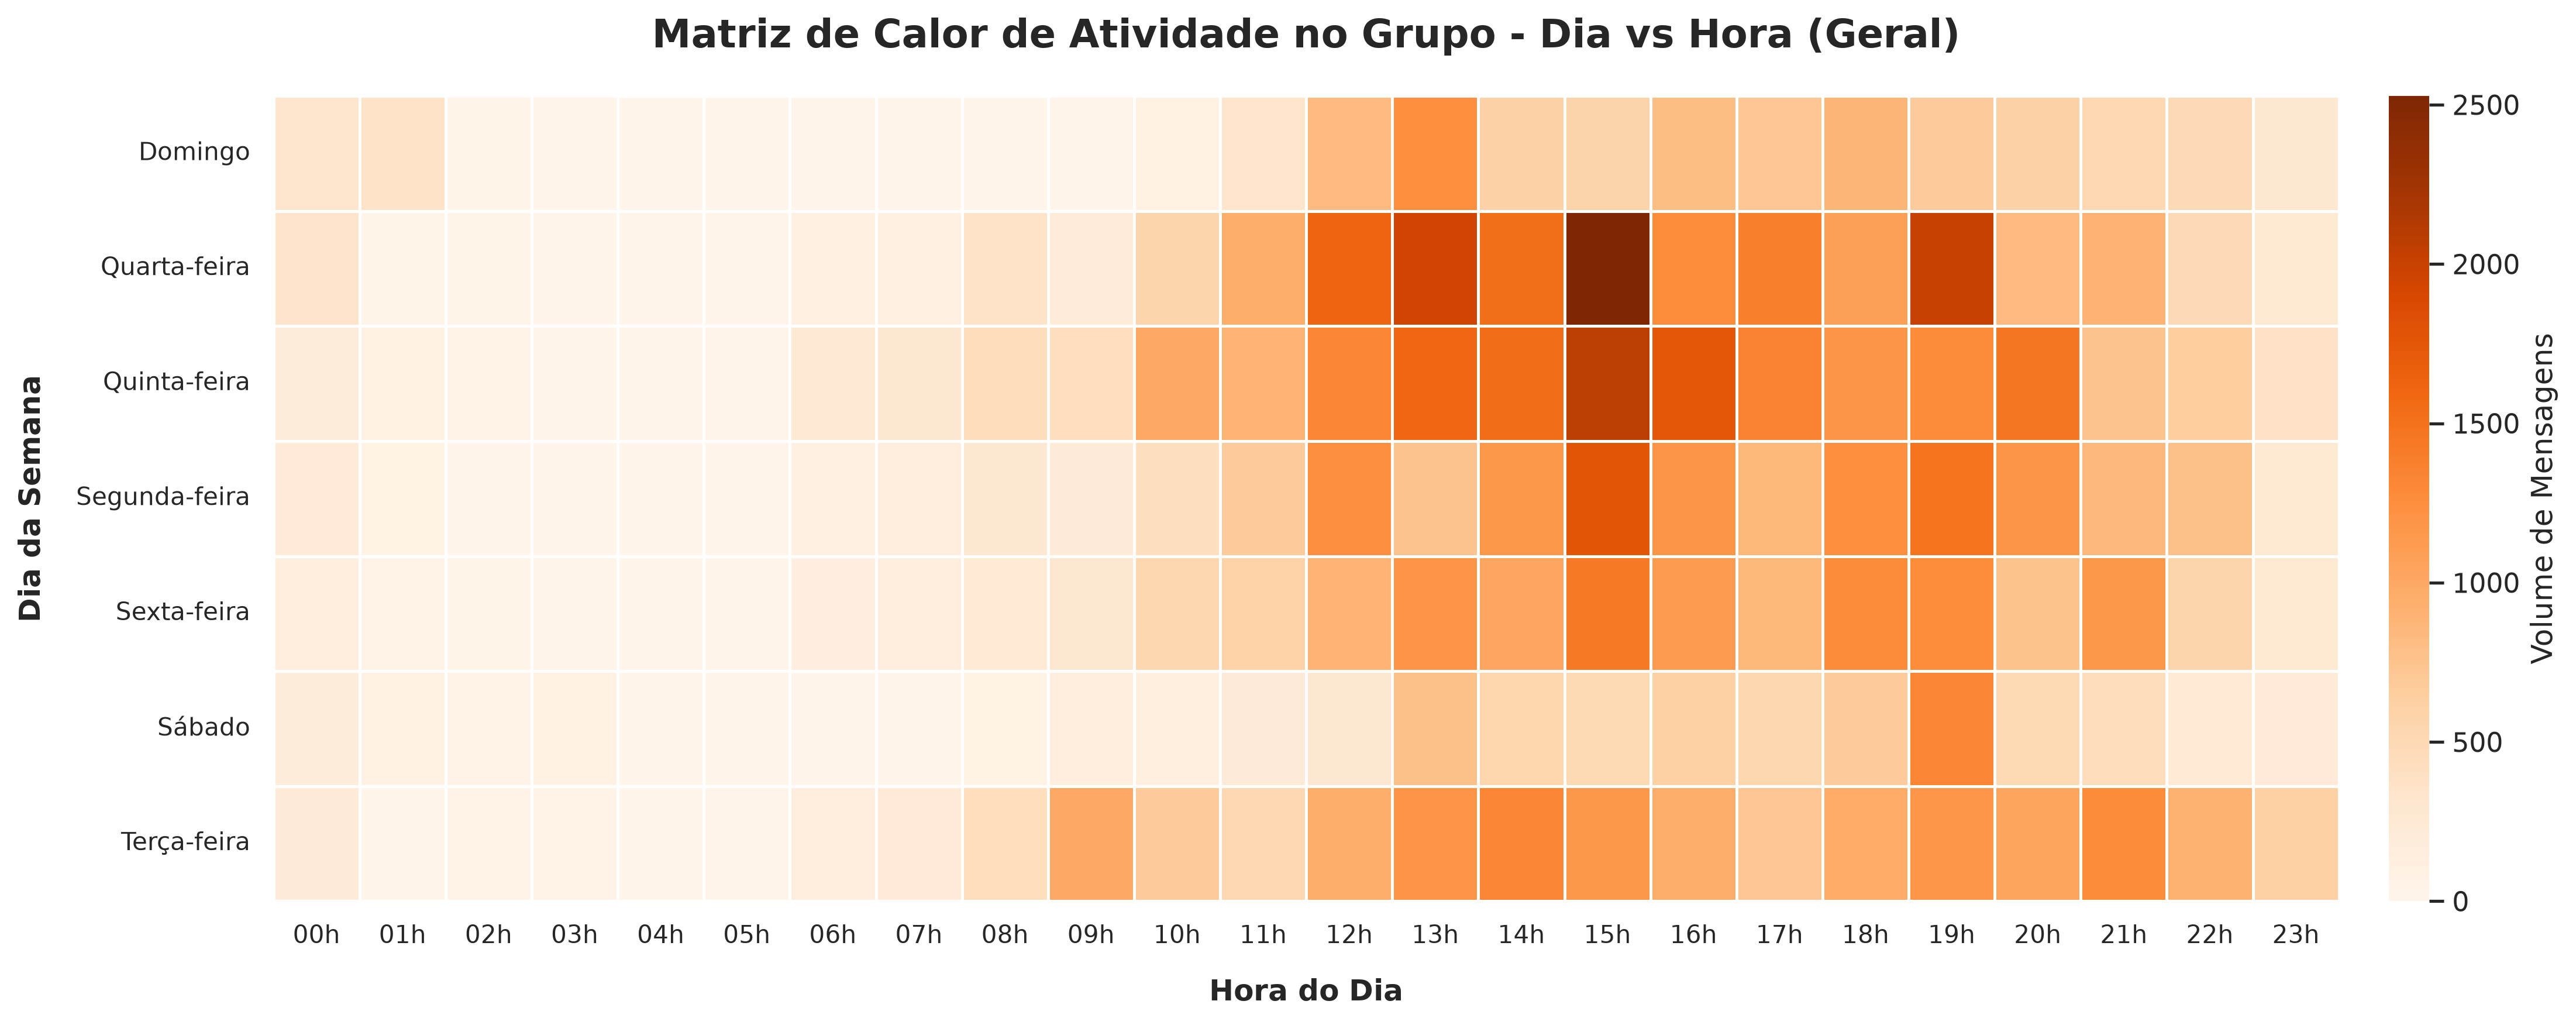

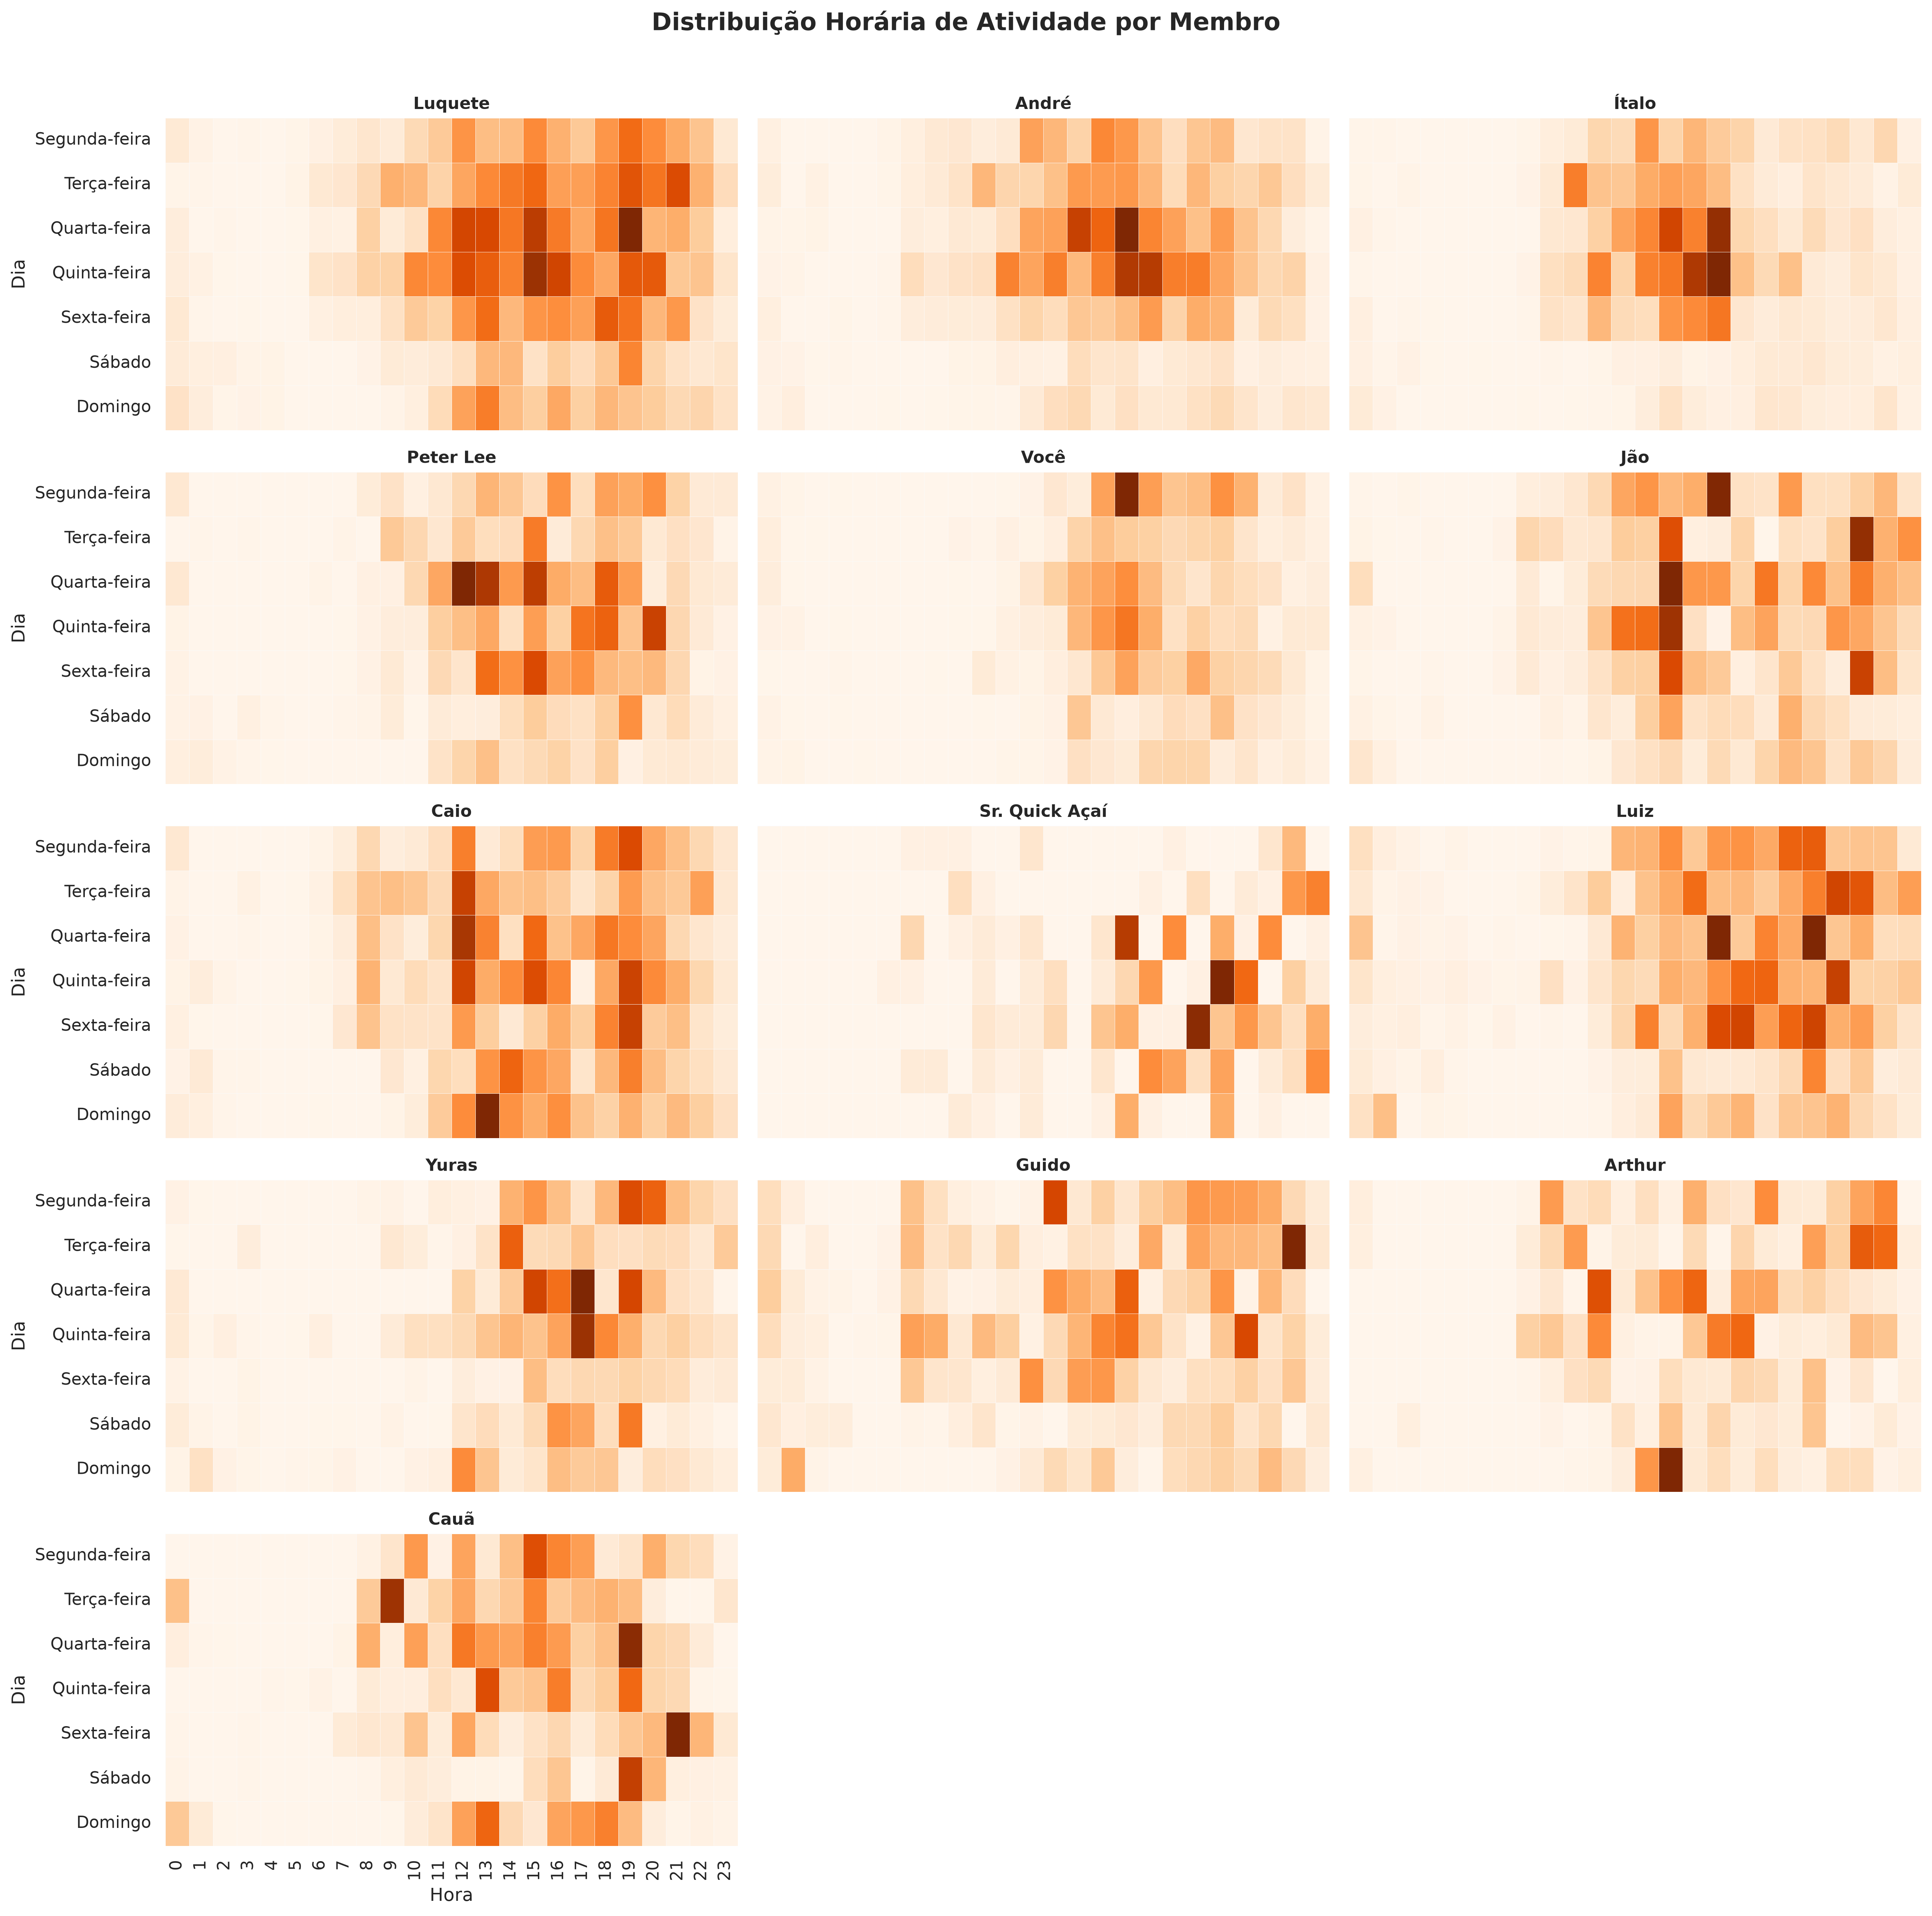

In [8]:
map_dias = {
    0: "Segunda-feira",
    1: "Terça-feira",
    2: "Quarta-feira",
    3: "Quinta-feira",
    4: "Sexta-feira",
    5: "Sábado",
    6: "Domingo"
}

dias_ordenados = [
    "Segunda-feira",
    "Terça-feira",
    "Quarta-feira",
    "Quinta-feira",
    "Sexta-feira",
    "Sábado",
    "Domingo",
]

df["dia"] = df["data_hora"].dt.dayofweek.map(map_dias)
df["hora"] = df["data_hora"].dt.hour

matriz_geral = pd.crosstab(df["dia"], df["hora"]).reindex(
    columns=range(24), fill_value=0
)

plt.figure(figsize=(16, 6), dpi=300)

ax = sns.heatmap(
    matriz_geral,
    cmap="Oranges",
    annot=False,
    cbar_kws={"label": "Volume de Mensagens", "pad": 0.02},
    linewidths=0.8,
    linecolor="white",
    square=False,  
)

plt.title(
    "Matriz de Calor de Atividade no Grupo - Dia vs Hora (Geral)",
    fontsize=16,
    fontweight="bold",
    pad=20,
)
plt.xlabel("Hora do Dia", fontsize=12, fontweight="bold", labelpad=12)
plt.ylabel("Dia da Semana", fontsize=12, fontweight="bold", labelpad=12)

plt.xticks(
    ticks=np.arange(24) + 0.5,
    labels=[f"{h:02d}h" for h in range(24)],
    rotation=0,
    fontsize=10,
    fontweight="medium",
)

plt.yticks(fontsize=10, rotation=0)

plt.tight_layout()
plt.show()

membros = df["membro"].unique()
num_membros = len(membros)

cols = 3
rows = (num_membros + cols - 1) // cols

fig, axes = plt.subplots(
    rows, cols, figsize=(18, rows * 3.5), sharex=True, sharey=True, dpi=300
)
axes = axes.flatten()

for i, membro in enumerate(membros):
    ax = axes[i]
    df_membro = df[df["membro"] == membro]

    matriz_membro = pd.crosstab(df_membro["dia"], df_membro["hora"]).reindex(
        index=dias_ordenados, columns=range(24), fill_value=0
    )

    sns.heatmap(
        matriz_membro,
        cmap="Oranges",
        cbar=False,
        ax=ax,
        linewidths=0.2,
        linecolor="#fafafa",
    )

    ax.set_title(f"{membro}", fontsize=11, fontweight="bold")
    ax.set_xlabel("" if i < (rows - 1) * cols else "Hora")
    ax.set_ylabel("" if i % cols != 0 else "Dia")
    ax.tick_params(axis="y", rotation=0)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Distribuição Horária de Atividade por Membro",
    fontsize=16,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()

Como o mapa de calor de atividade temporal é bem distribuída, vamos usar features temporais como preditoras.

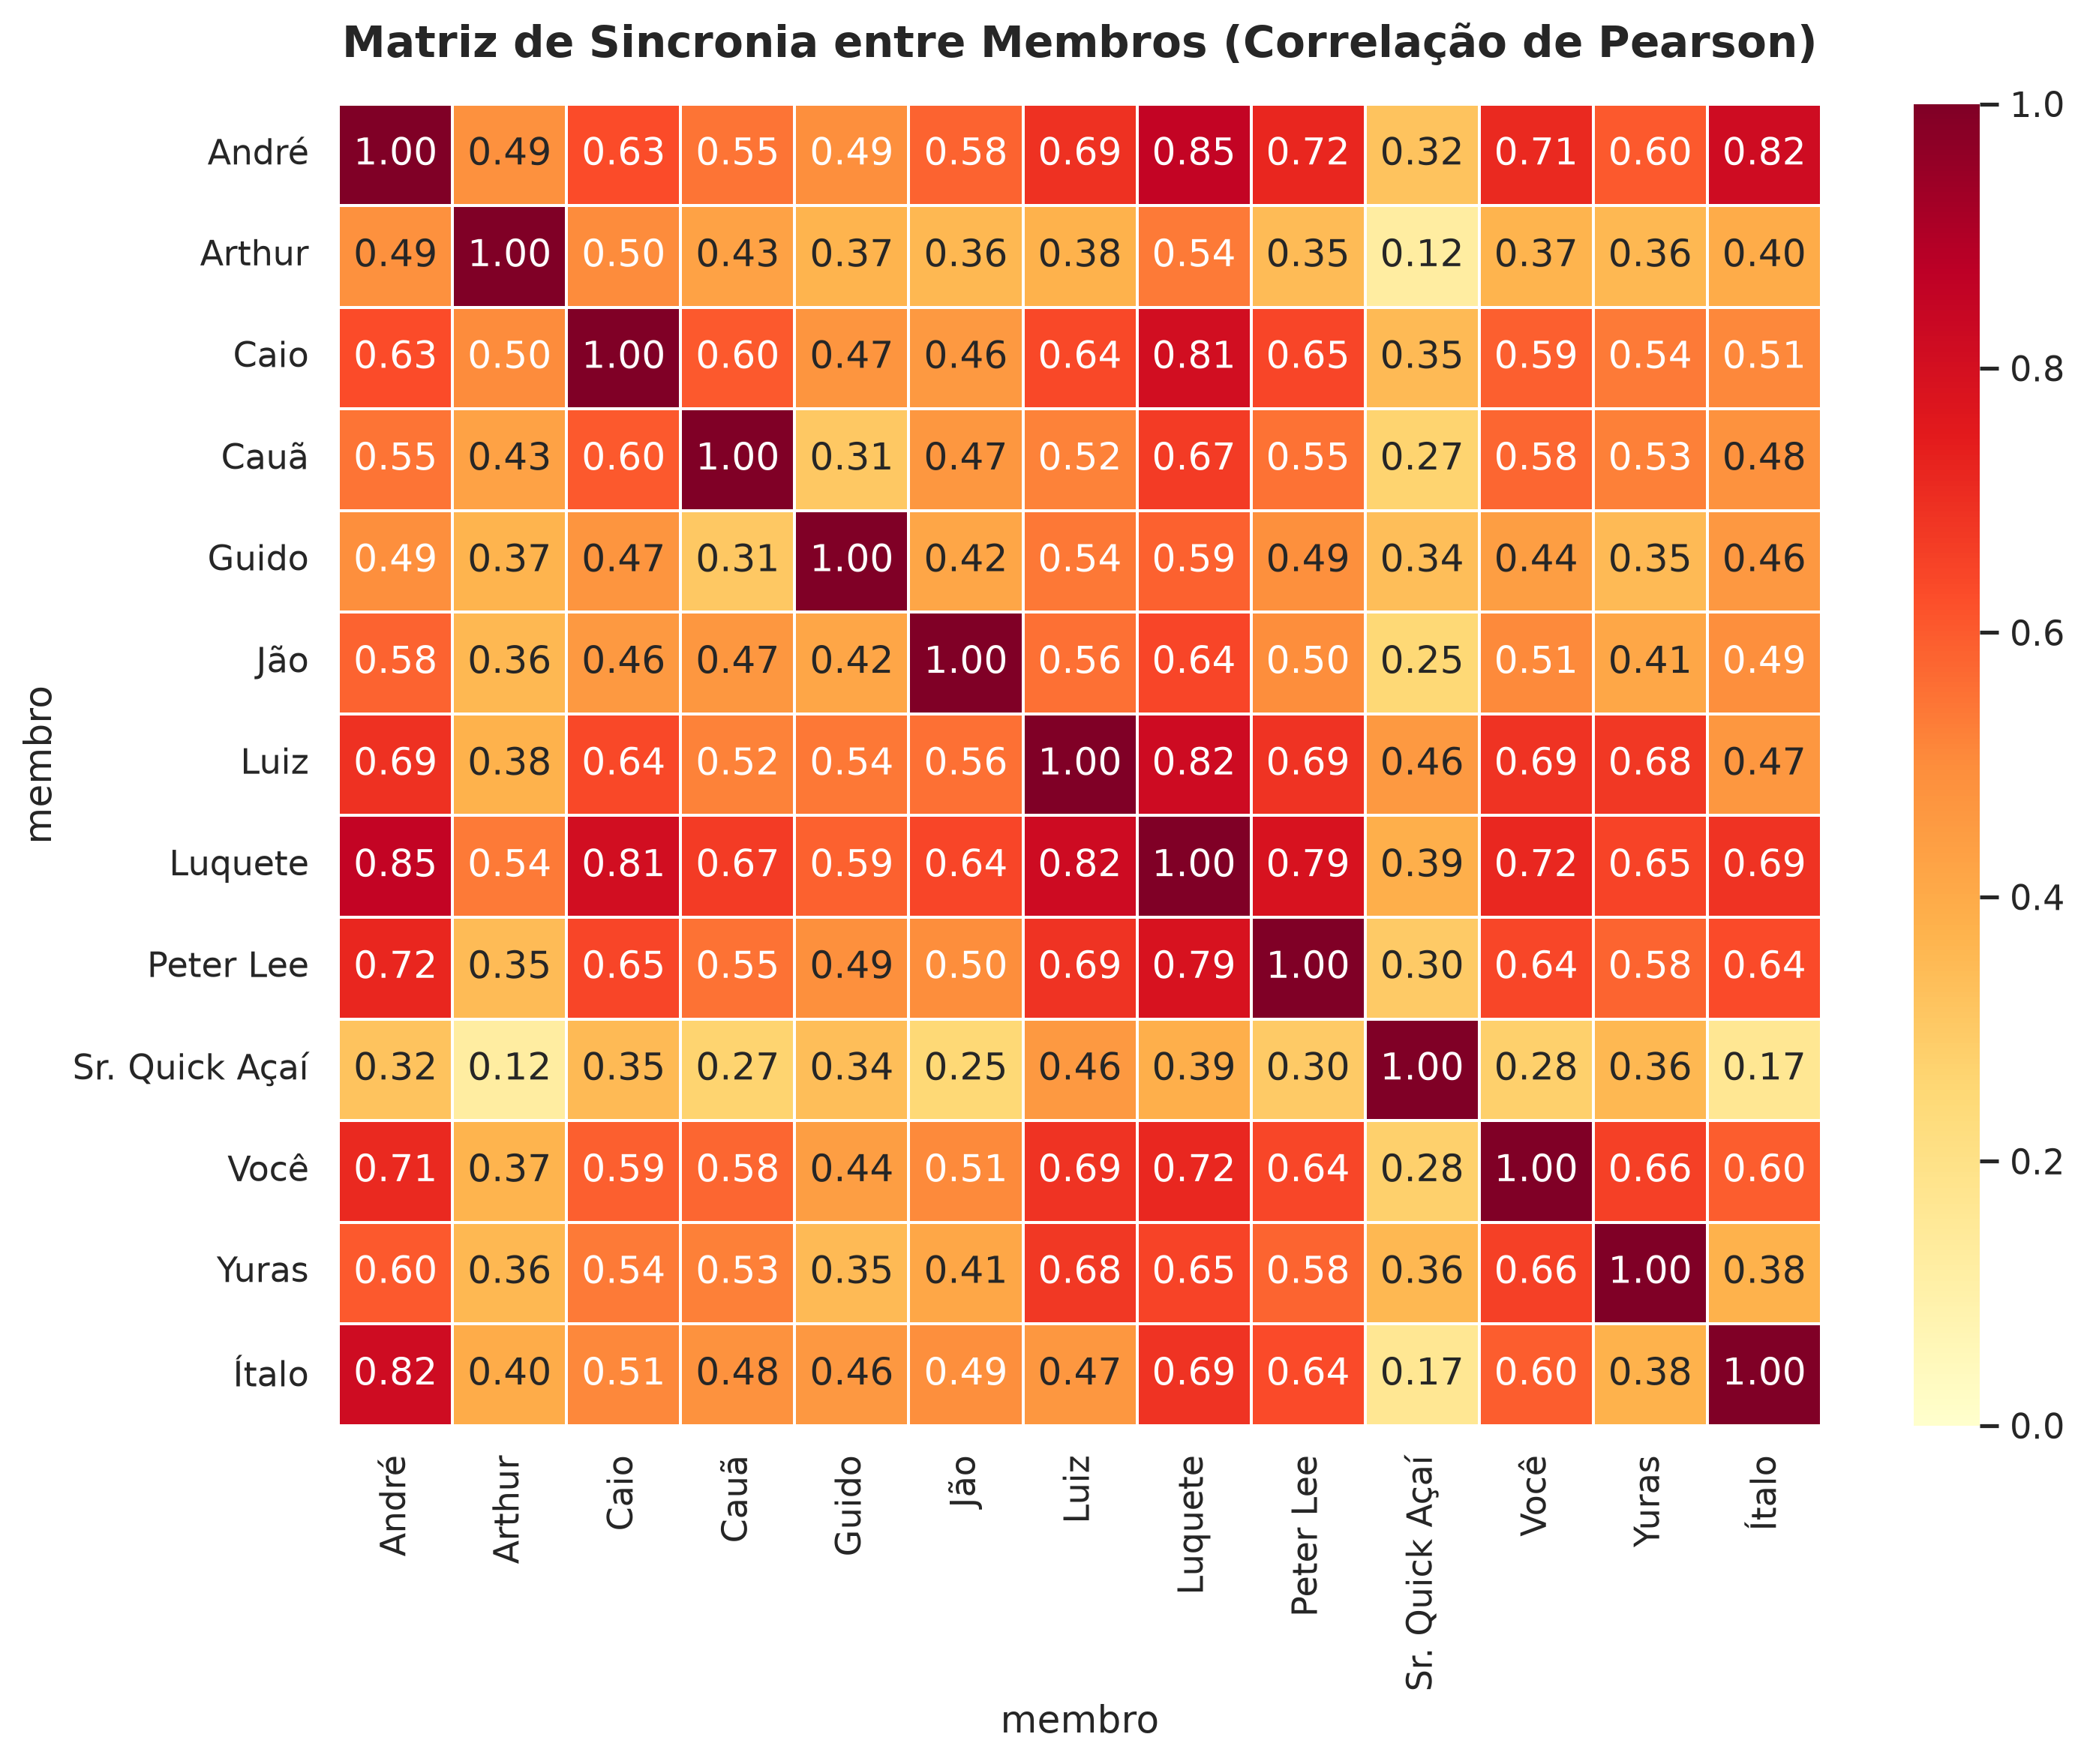

In [9]:
df["janela_tempo"] = df["dia"].astype(str) + " " + df["hora"].astype(str) + "h"

pivot_atividade = (
    df.groupby(["janela_tempo", "membro"])
    .size()
    .unstack(fill_value=0)
)

matriz_corr = pivot_atividade.corr(method="pearson")

plt.figure(figsize=(10, 8), dpi=300)
sns.heatmap(
    matriz_corr,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    linewidths=0.5,
)
plt.title(
    "Matriz de Sincronia entre Membros (Correlação de Pearson)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.tight_layout()
plt.show()

--- Tabela Descritiva de Densidade Textual ---
        membro  total_msgs  mediana_palavras  media_palavras  max_palavras  media_caracteres
          Caio        6778               4.0        5.373119           204         34.181617
       Luquete       20768               4.0        5.321215          1066         30.004911
          Você        7123               4.0        5.204970           337         28.693949
         Yuras        6687               4.0        4.944669           996         28.263795
          Luiz       12933               4.0        4.566767           288         28.089770
     Peter Lee        4779               4.0        4.444863           133         25.356769
Sr. Quick Açaí         384               3.0        4.307292            21         22.820312
         André        9570               3.0        4.249530           432         27.715569
        Arthur        2417               3.0        4.237898           514         24.700041
         Ítalo        8

/tmp/ipykernel_25617/2874493202.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


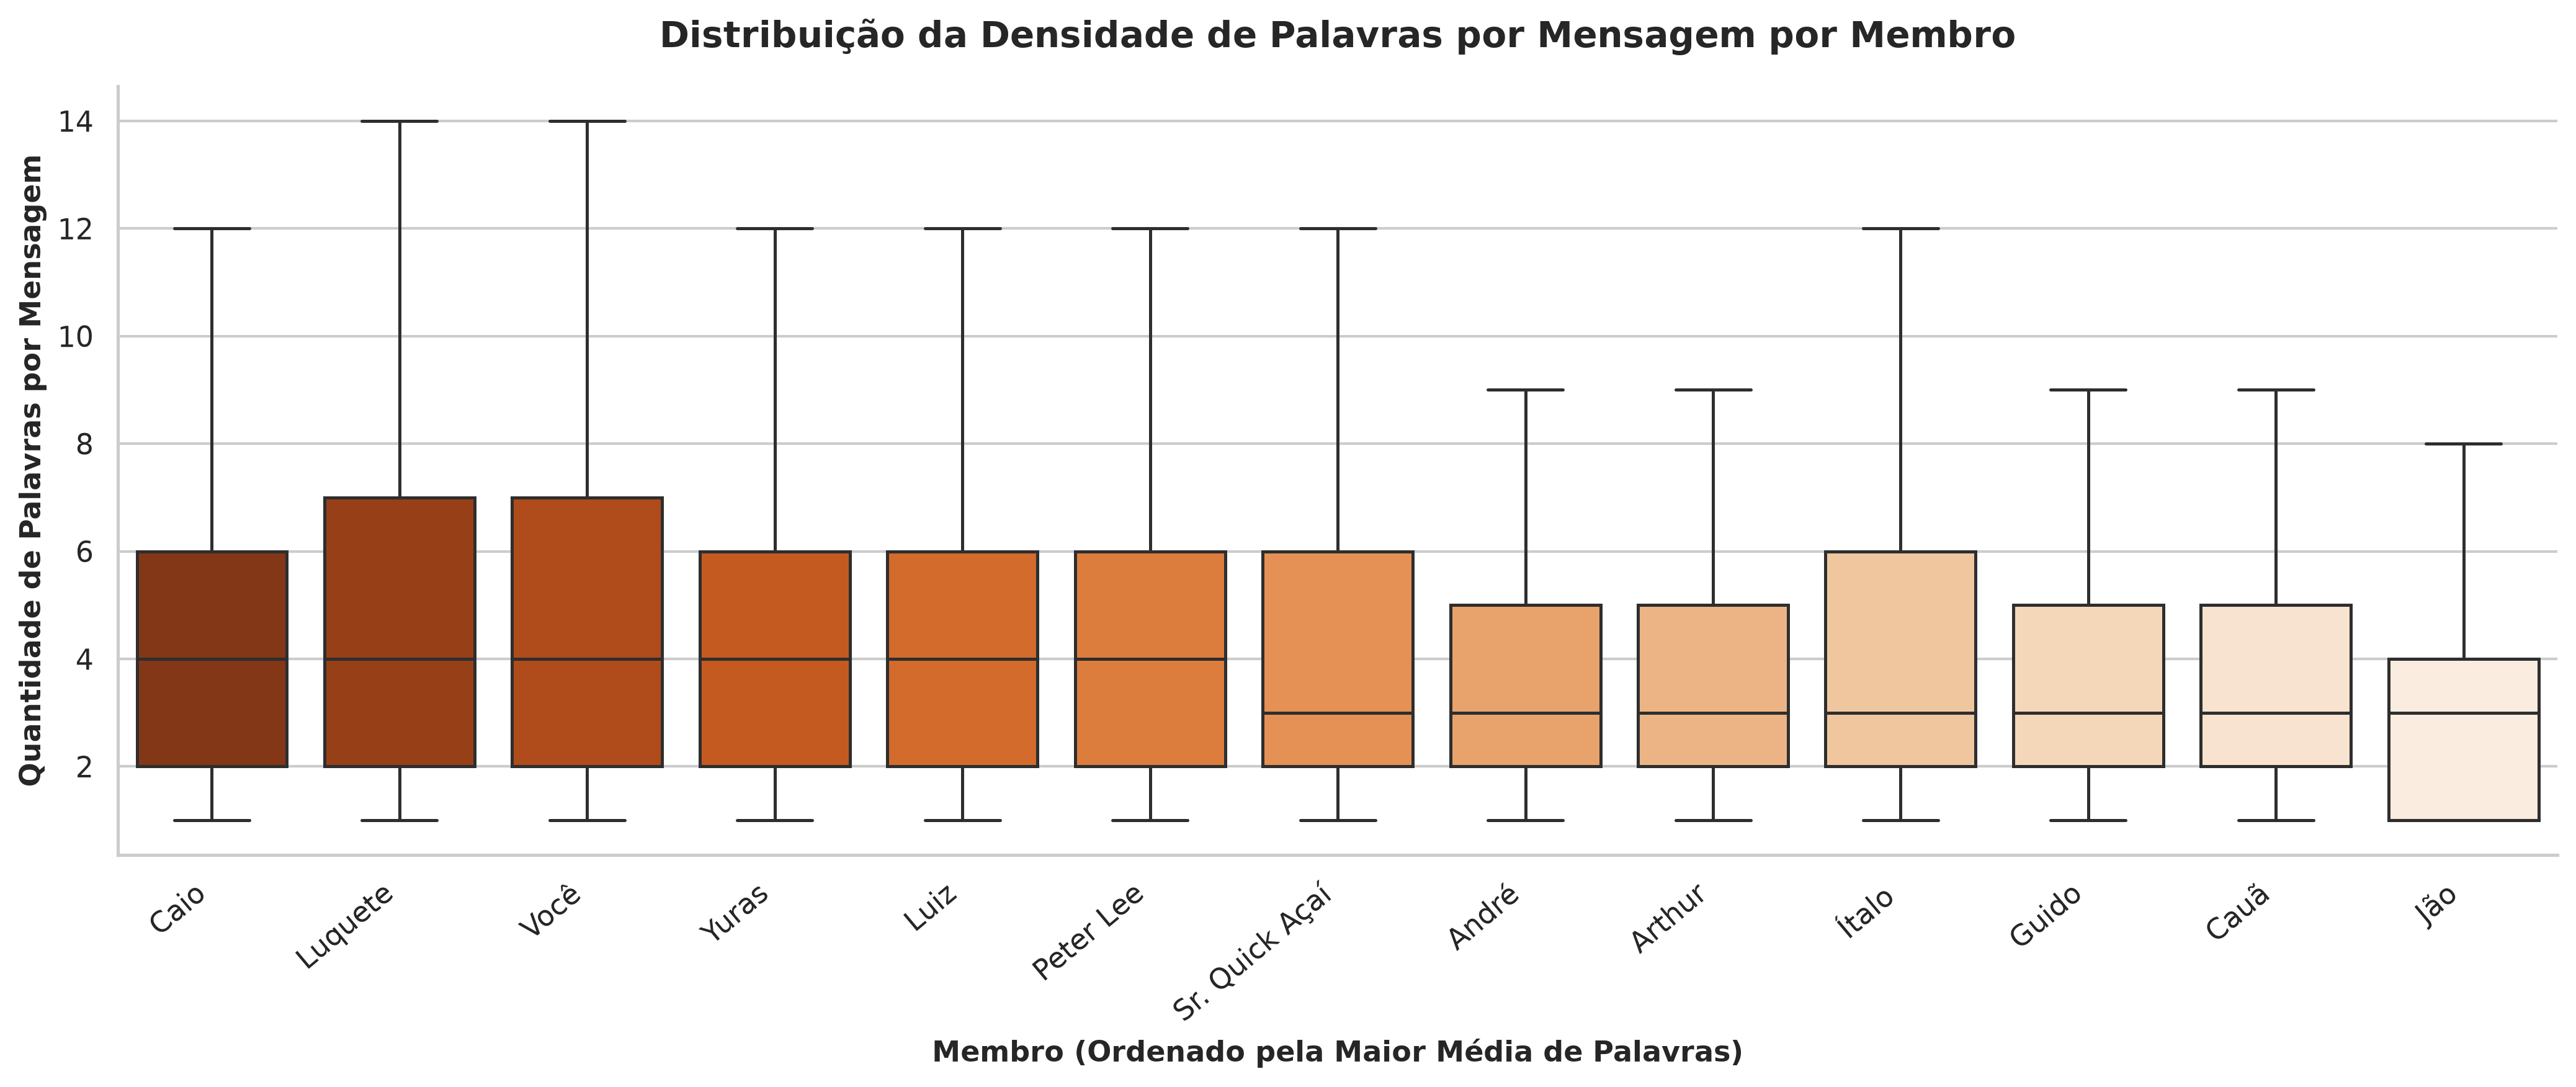

In [10]:
df["qtd_caracteres"] = df["mensagem"].astype(str).str.len()
df["qtd_palavras"] = (
    df["mensagem"].astype(str).apply(lambda x: len(x.split()))
)

estatisticas_texto = (
    df.groupby("membro")
    .agg(
        total_msgs=("mensagem", "count"),
        mediana_palavras=("qtd_palavras", "median"),
        media_palavras=("qtd_palavras", "mean"),
        max_palavras=("qtd_palavras", "max"),
        media_caracteres=("qtd_caracteres", "mean"),
    )
    .sort_values("media_palavras", ascending=False)
    .reset_index()
)

print("--- Tabela Descritiva de Densidade Textual ---")
print(estatisticas_texto.to_string(index=False))

plt.figure(figsize=(14, 6), dpi=300)

ax = sns.boxplot(
    data=df,
    x="membro",
    y="qtd_palavras",
    order=estatisticas_texto["membro"],
    palette="Oranges_r",
    showfliers=False,  # Esconde os outliers gigantes (textões isolados) para não achatar a escala
    linewidth=1.2,
)

plt.title(
    "Distribuição da Densidade de Palavras por Mensagem por Membro",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Membro (Ordenado pela Maior Média de Palavras)", fontsize=11, fontweight="bold")
plt.ylabel("Quantidade de Palavras por Mensagem", fontsize=11, fontweight="bold")
plt.xticks(rotation=40, ha="right")

sns.despine()
plt.tight_layout()
plt.show()

/tmp/ipykernel_25617/2931192947.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


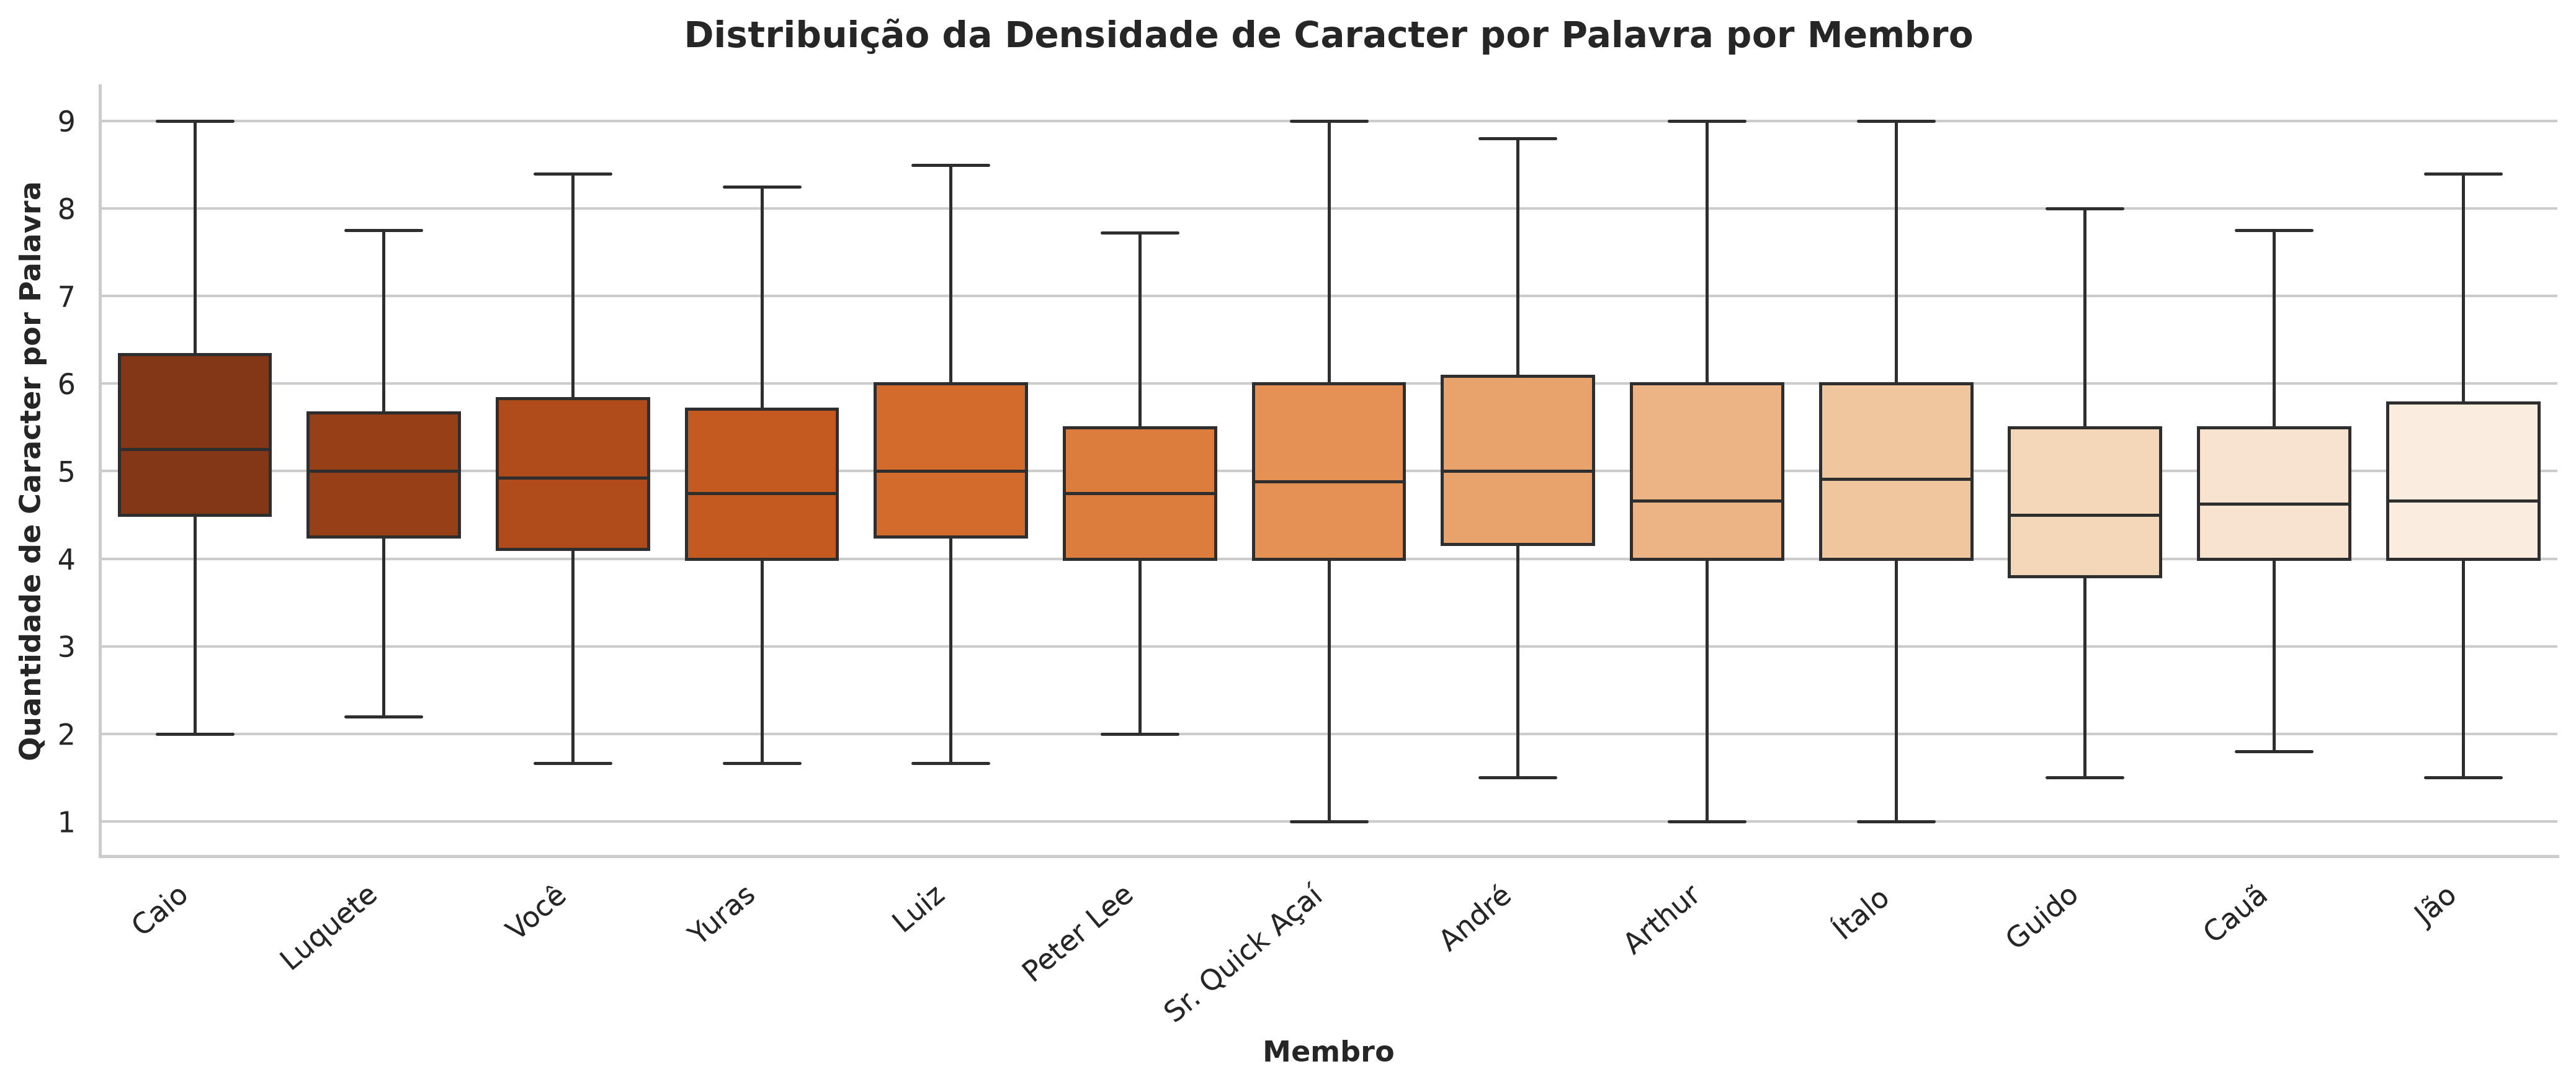

In [11]:
df["caracter_por_mensagem"] = (df["qtd_caracteres"] / df["qtd_palavras"]).clip(lower=1)

plt.figure(figsize=(14, 6), dpi=300)

ax = sns.boxplot(
    data=df,
    x="membro",
    y="caracter_por_mensagem",
    order=estatisticas_texto["membro"],
    palette="Oranges_r",
    showfliers=False,
    linewidth=1.2,
)

plt.title(
    "Distribuição da Densidade de Caracter por Palavra por Membro",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Membro", fontsize=11, fontweight="bold")
plt.ylabel("Quantidade de Caracter por Palavra", fontsize=11, fontweight="bold")
plt.xticks(rotation=40, ha="right")

sns.despine()
plt.tight_layout()
plt.show()

In [14]:
def limpar_para_embedding(texto):
    texto = str(texto).strip().lower()
    # remove apenas artefatos do WhatsApp / sistema
    texto = re.sub(r"https?://\S+|www\.\S+", "", texto)

    texto = re.sub(
        r"\b(unknown|null|omitid[oa]s?|ocultad[oa]s?|"
        r"imagem|figurinha|audio|áudio|video|vídeo|"
        r"mensagem|apagad[oa]s?|media|anexo|voz|"
        r"documento|contato|editad[oa]s?)\b",
        "",
        texto
    )
    texto = re.sub(r"\s+", " ", texto).strip()

    return texto

df["mensagem_embedding"] = df["mensagem"].apply(
    limpar_para_embedding
)
df = df[df["mensagem_embedding"].str.len() > 0].reset_index(drop=True)
df_clean = df[["membro", "mensagem_embedding", "dia", "hora", "qtd_caracteres", "qtd_palavras", "caracter_por_mensagem"]]

print("Primeiras linhas dos dados")
print(df_clean.head())
print("Informações adicionais")
print(df_clean.info())
print("Total de valores nulos")
print(df_clean.isnull().sum())

Primeiras linhas dos dados
    membro              mensagem_embedding          dia  hora  qtd_caracteres  \
0  Luquete                     não precisa  Terça-feira    14              11   
1  Luquete  e só colocar barco no enderman  Terça-feira    14              30   
2    André       onde fica os piglin bruto  Terça-feira    14              25   
3  Luquete       ele não consegue te bater  Terça-feira    14              25   
4    André                     vai demorar  Terça-feira    14              11   

   qtd_palavras  caracter_por_mensagem  
0             2                    5.5  
1             6                    5.0  
2             5                    5.0  
3             5                    5.0  
4             2                    5.5  
Informações adicionais
<class 'pandas.DataFrame'>
RangeIndex: 98694 entries, 0 to 98693
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   membro     

In [22]:
from sklearn.model_selection import train_test_split

y = df_clean["membro"]
X = df_clean.drop(columns=["membro"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

df_train = pd.concat([X_train, y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

In [23]:
print("Primeiras linhas dos dados de treino")
print(df_train.head())
print("Informações adicionais de treino")
print(df_train.info())
print("Total de valores nulos de treino")
print(df_train.isnull().sum())

Primeiras linhas dos dados de treino
                                      mensagem_embedding            dia  hora  \
42948                  dois zagueiros e os dois volantes    Sexta-feira    15   
97901                                            caralho  Segunda-feira    15   
73466                                    ela deixou mano    Sexta-feira    21   
7265   eu sinto que virei uma pessoa muito pior depoi...   Quinta-feira    19   
25371                                              calma   Quarta-feira    11   

       qtd_caracteres  qtd_palavras  caracter_por_mensagem   membro  
42948              33             6                  5.500     Luiz  
97901               7             1                  7.000    André  
73466              15             3                  5.000  Luquete  
7265              117            24                  4.875  Luquete  
25371               5             1                  5.000  Luquete  
Informações adicionais de treino
<class 'pandas.DataFram

In [24]:
print("Primeiras linhas dos dados de teste")
print(df_test.head())
print("Informações adicionais de teste")
print(df_test.info())
print("Total de valores nulos de teste")
print(df_test.isnull().sum())

Primeiras linhas dos dados de teste
                                      mensagem_embedding           dia  hora  \
89213              a betina nunca foi fã do lucas também  Quarta-feira    15   
23045  mano pessoal do trabalho descobriu meu nick do...   Sexta-feira    15   
26097     porque seu chat é um ignóbil debil mental mano  Quinta-feira    17   
403                                  nem durou até 00:00   Terça-feira    22   
90830                                          quem dera   Sexta-feira    13   

       qtd_caracteres  qtd_palavras  caracter_por_mensagem   membro  
89213              37             8               4.625000     Caio  
23045              59            10               5.900000    Ítalo  
26097              46             9               5.111111    André  
403                19             4               4.750000  Luquete  
90830               9             2               4.500000     Caio  
Informações adicionais de teste
<class 'pandas.DataFrame'>
Inde

In [27]:
df_train.to_parquet("../dados/processed/train.parquet", index=False)
df_test.to_parquet("../dados/processed/test.parquet", index=False)

Agora podemos prosseguir para NLP com Embeddings e TL-IDF no próximo notebook.